# 6 Robot Version

## Import Libraries

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy import linalg
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

## Vector Field

In [18]:
class VectorField:
    """Vector field with two counter-rotating vortices."""
    
    def __init__(self):
        self.vortex1_pos = np.array([-2, 0])
        self.vortex2_pos = np.array([2, 0])
        
    def evaluate(self, x, y):
        """Evaluate the vector field at position (x, y)."""
        # Left vortex (counterclockwise)
        x1, y1 = self.vortex1_pos
        vx1 = -(y - y1)
        vy1 = (x - x1)
        
        # Right vortex (clockwise)
        x2, y2 = self.vortex2_pos
        vx2 = (y - y2)
        vy2 = -(x - x2)

        # Combine with distance-based weighting
        d1 = np.sqrt((x - x1)**2 + (y - y1)**2)
        d2 = np.sqrt((x - x2)**2 + (y - y2)**2)
        w1 = 1.0 / (d1**2 + 0.1)
        w2 = 1.0 / (d2**2 + 0.1)
        vx = (vx1 * w1 + vx2 * w2) / (w1 + w2)
        vy = (vy1 * w1 + vy2 * w2) / (w1 + w2)
        return np.array([10*vx, 10*vy])
    
    def jacobian_twosided(self, x, y, h=0.01):
        """Compute Jacobian using two-sided finite differences."""
        fx_plus, fy_plus = self.evaluate(x + h, y)
        fx_minus, fy_minus = self.evaluate(x - h, y)
        fx_yplus, fy_yplus = self.evaluate(x, y + h)
        fx_yminus, fy_yminus = self.evaluate(x, y - h)
        
        J = np.array([
            [(fx_plus - fx_minus) / (2*h), (fx_yplus - fx_yminus) / (2*h)],
            [(fy_plus - fy_minus) / (2*h), (fy_yplus - fy_yminus) / (2*h)]
        ])
        return J

## Robot Cluster

In [19]:
class RobotCluster6:
    """Cluster of 6 robots for vector field navigation."""
    
    def __init__(self, num_robots=6, formation_radius=0.2):
        self.num_robots = num_robots
        self.formation_radius = formation_radius
        self.positions = np.zeros((num_robots, 2))
        self.centroid = np.array([0.1, 2.2])
        self.vector_readings = np.zeros((num_robots, 2))
        
        # Fixed formation angle
        self.formation_angle = np.pi/4  # 45 degrees
        self._update_robot_positions()
        
    def _update_robot_positions(self):
        """Update robot positions based on formation.
        Robots 1,2,3 form equilateral triangle.
        Robot 4 is midway between 1 and 2.
        Robot 5 is midway between 2 and 3.
        Robot 6 is midway between 3 and 1.
        """
        # Main triangle vertices (robots 1, 2, 3)
        angles = np.array([0, 2*np.pi/3, 4*np.pi/3]) + self.formation_angle
        
        # Vertices of equilateral triangle
        for i in range(3):
            self.positions[i] = self.centroid + self.formation_radius * np.array([np.cos(angles[i]), np.sin(angles[i])])
        
        # Midpoints (robots 4, 5, 6)
        self.positions[3] = (self.positions[0] + self.positions[1]) / 2  # Robot 4: midpoint of 1-2
        self.positions[4] = (self.positions[1] + self.positions[2]) / 2  # Robot 5: midpoint of 2-3
        self.positions[5] = (self.positions[2] + self.positions[0]) / 2  # Robot 6: midpoint of 3-1
    
    def update_readings(self, vector_field):
        """Update vector field readings at each robot position."""
        for i in range(self.num_robots):
            x, y = self.positions[i]
            self.vector_readings[i] = vector_field.evaluate(x, y)
    
    def compute_jacobian(self):
        """Compute Jacobian using least squares with all 6 robots."""
        A = np.column_stack([self.positions[:, 0], self.positions[:, 1], np.ones(self.num_robots)])
        b_u = self.vector_readings[:, 0]
        b_v = self.vector_readings[:, 1]
        
        try:
            coeffs_u, _, _, _ = np.linalg.lstsq(A, b_u, rcond=None)
            coeffs_v, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
            
            J = np.array([
                [coeffs_u[0], coeffs_u[1]],
                [coeffs_v[0], coeffs_v[1]]
            ])
            return J, None
            
        except np.linalg.LinAlgError:
            return None, None
    
    def compute_determinant_gradient(self):
        """Compute gradient of det(J) using 3 sub-triangles.
        Triangle 1: robots 1, 4, 6 (indices 0, 3, 5)
        Triangle 2: robots 2, 4, 5 (indices 1, 3, 4)
        Triangle 3: robots 3, 5, 6 (indices 2, 4, 5)
        """
        J_current, _ = self.compute_jacobian()
        if J_current is None:
            return np.array([0.0, 0.0])
    
        det_current = np.linalg.det(J_current)
        
        # Define the three sub-triangles
        triangles = [
            [0, 3, 5],  # robots 1, 4, 6
            [1, 3, 4],  # robots 2, 4, 5
            [2, 4, 5]   # robots 3, 5, 6
        ]
        
        determinants = []
        centroids = []
        
        for triangle_indices in triangles:
            pos_subset = self.positions[triangle_indices]
            readings_subset = self.vector_readings[triangle_indices]
            centroid = np.mean(pos_subset, axis=0)
            
            # Set up 3x3 system
            A = np.column_stack([pos_subset[:, 0], pos_subset[:, 1], np.ones(3)])
            b_u = readings_subset[:, 0]
            b_v = readings_subset[:, 1]
            
            try:
                coeffs_u, _, _, s_u = np.linalg.lstsq(A, b_u, rcond=None)
                coeffs_v, _, _, s_v = np.linalg.lstsq(A, b_v, rcond=None)
                
                condition_number = s_u[0] / s_u[-1] if len(s_u) > 0 and s_u[-1] > 1e-12 else np.inf
                if condition_number > 1e8:
                    continue
                
                J = np.array([[coeffs_u[0], coeffs_u[1]], [coeffs_v[0], coeffs_v[1]]])
                det_J = np.linalg.det(J)
                
                determinants.append(det_J)
                centroids.append(centroid)
                
            except np.linalg.LinAlgError:
                continue
        
        if len(centroids) < 3:
            return np.array([0.0, 0.0])
        
        # Fit plane to compute gradient
        centroids = np.array(centroids)
        determinants = np.array(determinants)
        print('determinants', determinants)
        A_grad = np.column_stack([centroids[:, 0], centroids[:, 1], np.ones(len(centroids))])
        
        try:
            coeffs, _, _, _ = np.linalg.lstsq(A_grad, determinants, rcond=None)
            gradient = np.array([coeffs[0], coeffs[1]])
            
            if np.linalg.norm(gradient) > 1e-10:
                correction_direction = -np.sign(det_current) * gradient
                correction_direction = correction_direction / np.linalg.norm(correction_direction)
            else:
                correction_direction = np.array([0.0, 0.0])
            
            return correction_direction
            
        except np.linalg.LinAlgError:
            return np.array([0.0, 0.0])
    
    def update_positions(self, delta):
        """Update cluster position."""
        self.centroid += delta
        self._update_robot_positions()

## Visualizations

In [20]:
def visualize_results(centroid_history, eigenvector_history, robots, plot_field=True):
    """Visualize robot trajectory and vector field."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 8)
    
    if plot_field:
        x = np.linspace(-5, 5, 20)
        y = np.linspace(-2, 8, 20)
        X, Y = np.meshgrid(x, y)
        
        vf = VectorField()
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                U[i, j], V[i, j] = vf.evaluate(X[i, j], Y[i, j])
        
        magnitude = np.sqrt(U**2 + V**2)
        U = U / magnitude
        V = V / magnitude
        
        ax.quiver(X, Y, U, V, alpha=0.3, color='gray')
    
    # Plot eigenvectors
    for pos, eigvec in eigenvector_history[::10]:
        ax.arrow(pos[0], pos[1], eigvec[0]*0.2, eigvec[1]*0.2, 
                head_width=0.05, head_length=0.08, fc='green', ec='green', alpha=0.5)
    
    # Plot robot positions
    for i, pos in enumerate(robots.positions):
        ax.scatter(pos[0], pos[1], c='blue', marker='o', s=100)
        circle = Circle(pos, 0.05, fill=False, color='blue')
        ax.add_patch(circle)
        ax.text(pos[0]+0.05, pos[1]+0.05, f'R{i+1}')
    
    # Plot trajectory
    ax.plot(centroid_history[:, 0], centroid_history[:, 1], 'b-', alpha=0.7, label='Cluster Path')
    ax.scatter(centroid_history[0, 0], centroid_history[0, 1], c='green', marker='o', s=100, label='Start')
    ax.scatter(centroid_history[-1, 0], centroid_history[-1, 1], c='red', marker='o', s=100, label='End')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('6-Robot Cluster Following Separatrix')
    ax.legend()
    ax.grid(True)
    
    plt.tight_layout()
    return fig

def compute_field_properties(vector_field, x_range=(-5, 5), y_range=(-5, 5), resolution=50):
    """Compute vector field properties using two-sided differences."""
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    determinant = np.zeros_like(X)
    trace = np.zeros_like(X)
    
    for i in range(len(y)):
        for j in range(len(x)):
            u, v = vector_field.evaluate(X[i, j], Y[i, j])
            U[i, j] = u
            V[i, j] = v
            
            try:
                J = vector_field.jacobian_twosided(X[i, j], Y[i, j])
                determinant[i, j] = np.linalg.det(J)
                trace[i, j] = np.trace(J)
            except:
                determinant[i, j] = np.nan
                trace[i, j] = np.nan
    
    return X, Y, U, V, determinant, trace

def create_comprehensive_visualization(resolution=50):
    """Create comprehensive field analysis visualization."""
    vf = VectorField()
    X, Y, U, V, det, tr = compute_field_properties(vf, resolution=resolution)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Vector Field Analysis: Two Vortices', fontsize=20, fontweight='bold', y=0.98)
    
    # Stream plot
    ax1.streamplot(X, Y, U, V, density=2, color='navy', linewidth=1.5)
    ax1.quiver(X[::4, ::4], Y[::4, ::4], U[::4, ::4], V[::4, ::4], 
               alpha=0.6, scale=50, color='red', width=0.003)
    ax1.plot(-2, 0, 'ro', markersize=10, label='Left Vortex')
    ax1.plot(2, 0, 'bo', markersize=10, label='Right Vortex')
    ax1.set_title('Stream Plot with Vector Field', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Determinant
    det_clean = np.where(np.isfinite(det), det, 0)
    im2 = ax2.contourf(X, Y, det_clean, levels=50, cmap='RdBu_r')
    ax2.contour(X, Y, det_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    ax2.set_title('Determinant of Jacobian', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.grid(True, alpha=0.3)
    
    # Trace
    tr_clean = np.where(np.isfinite(tr), tr, 0)
    im3 = ax3.contourf(X, Y, tr_clean, levels=50, cmap='coolwarm')
    ax3.contour(X, Y, tr_clean, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im3, ax=ax3, shrink=0.8)
    ax3.set_title('Trace of Jacobian', fontsize=14, fontweight='bold')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.grid(True, alpha=0.3)
    
    # Gradient of determinant
    grad_det_y, grad_det_x = np.gradient(det_clean, Y[:, 0], X[0, :])
    grad_magnitude = np.sqrt(grad_det_x**2 + grad_det_y**2)
    
    im4 = ax4.contourf(X, Y, grad_magnitude, levels=50, cmap='plasma')
    plt.colorbar(im4, ax=ax4, shrink=0.8, label='Gradient Magnitude')
    
    skip = 3
    ax4.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
               grad_det_x[::skip, ::skip], grad_det_y[::skip, ::skip],
               alpha=0.7, scale=None, color='white', width=0.003)
    
    ax4.set_title('Gradient of Determinant', fontsize=14, fontweight='bold')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    print(f"\nDeterminant range: [{np.nanmin(det):.3f}, {np.nanmax(det):.3f}]")
    print(f"Trace range: [{np.nanmin(tr):.3f}, {np.nanmax(tr):.3f}]")
    print(f"Gradient magnitude range: [{np.nanmin(grad_magnitude):.3f}, {np.nanmax(grad_magnitude):.3f}]")
    
    return fig

## Separatrix Following

In [21]:
def simulate_separatrix_following(n_steps=500, step_size=0.02, 
                                 correction_weight=0.5, verbose=True):
    """Simulate robot cluster following separatrix.
    
    Parameters:
    -----------
    n_steps : int
        Number of simulation steps
    step_size : float
        Step size for position updates
    correction_weight : float
        Weight for determinant gradient correction
    verbose : bool
        Print debug information
    """
    vector_field = VectorField()
    robots = RobotCluster6(num_robots=6, formation_radius=0.3)
    
    centroid_history = np.zeros((n_steps, 2))
    eigenvector_history = []
    
    for step in range(n_steps):
        centroid_history[step] = robots.centroid
        robots.update_readings(vector_field)
        
        correction_direction = robots.compute_determinant_gradient()
        J, _ = robots.compute_jacobian()
        
        if J is not None:
            eigvals, eigvecs = np.linalg.eig(J)
            actual_flow = np.mean(robots.vector_readings, axis=0)
            actual_flow_norm = actual_flow / np.linalg.norm(actual_flow)
            
            # Choose eigenvector aligned with flow
            eigvec1 = np.real(eigvecs[:, 0])
            eigvec2 = np.real(eigvecs[:, 1])
            eigvec1 = eigvec1 / np.linalg.norm(eigvec1)
            eigvec2 = eigvec2 / np.linalg.norm(eigvec2)
            
            dot1 = abs(np.dot(actual_flow_norm, eigvec1))
            dot2 = abs(np.dot(actual_flow_norm, eigvec2))
            
            primary_eigvec = eigvec1 if dot1 > dot2 else eigvec2
            
            # Ensure consistent direction
            if np.dot(primary_eigvec, actual_flow_norm) < 0:
                primary_eigvec = -primary_eigvec
            
            # Compute direction with orthogonal correction
            correction_parallel = np.dot(correction_direction, primary_eigvec) * primary_eigvec
            correction_orthogonal = correction_direction - correction_parallel
            direction = primary_eigvec + correction_weight * correction_orthogonal
            
            eigenvector_history.append((robots.centroid.copy(), primary_eigvec.copy()))
            
            print('centroid', robots.centroid)
            print(['Primary eigenvector', primary_eigvec])
            print('correction', correction_direction)
            print('direction', direction)

            if verbose and step % 100 == 0:
                det = np.linalg.det(J)
                print(f"Step {step}: det(J) = {det:.4f}, centroid = {robots.centroid}")
        else:
            # Fallback to average flow
            avg_vector = np.mean(robots.vector_readings, axis=0)
            avg_vector_norm = np.linalg.norm(avg_vector)
            direction = avg_vector / avg_vector_norm if avg_vector_norm > 0 else np.array([0, 1])
        
        robots.update_positions(step_size * direction)
    
    return centroid_history, eigenvector_history, robots

## Main

Creating comprehensive field visualization...

Determinant range: [0.006, 114.375]
Trace range: [-9.855, 9.855]
Gradient magnitude range: [0.108, 125.820]


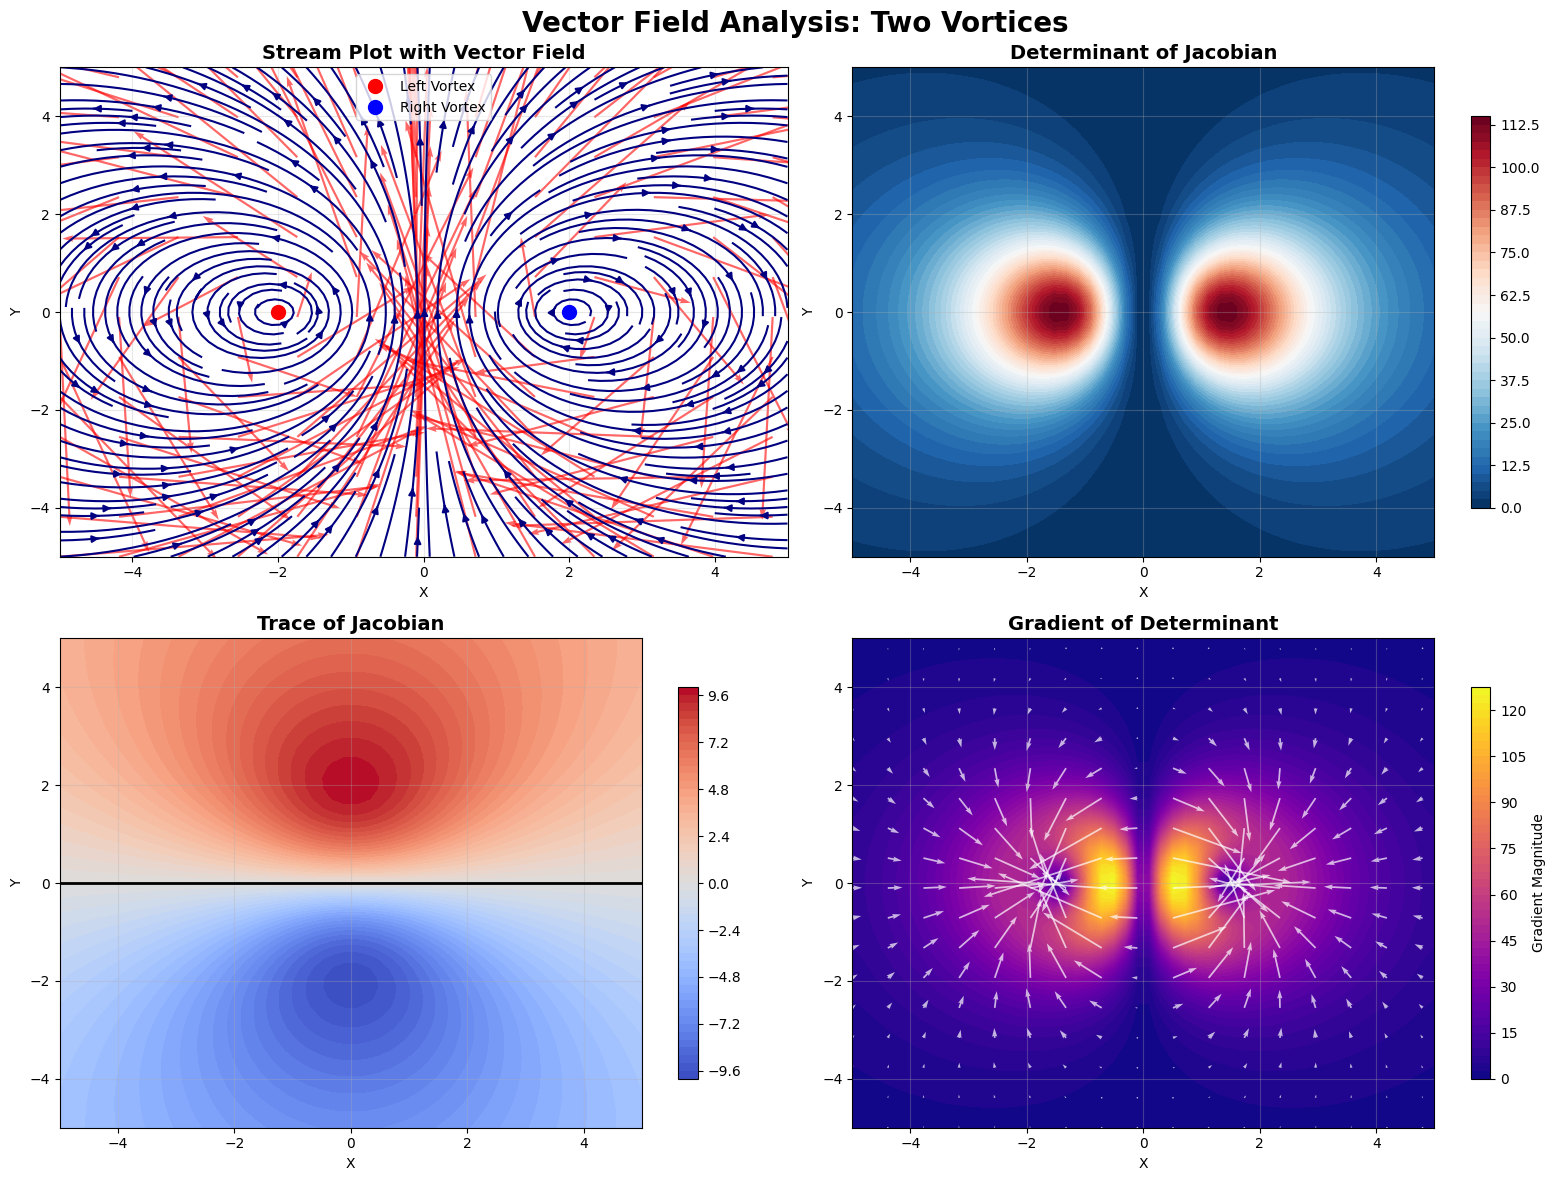



Simulating 6-Robot Cluster
determinants [-0.94584589 -2.20913751 -1.56748115]
centroid [0.1 2.2]
['Primary eigenvector', array([0.00702606, 0.99997532])]
correction [0.9682535  0.24997031]
direction [9.75850093 0.9314592 ]
Step 0: det(J) = -2.2971, centroid = [0.1 2.2]
determinants [ 0.03782626 -1.97676731 -0.4760664 ]
centroid [0.19758501 2.20931459]
['Primary eigenvector', array([0.01161787, 0.99993251])]
correction [ 0.99990468 -0.01380662]
direction [10.10091273  0.88270849]
determinants [ 1.29861431 -1.37927458  1.03646564]
centroid [0.29859414 2.21814168]
['Primary eigenvector', array([0.01598104, 0.99987229])]
correction [ 0.98509126 -0.17203261]
direction [9.9807498  0.84060455]
determinants [ 2.73868735 -0.46299094  2.84545792]
centroid [0.39840163 2.22654772]
['Primary eigenvector', array([0.01965301, 0.99980686])]
correction [-0.95818707  0.2861425 ]
direction [-9.70145113  1.19089277]
determinants [ 1.27517843 -1.35191253  1.02205922]
centroid [0.30138712 2.23845665]
['Pr

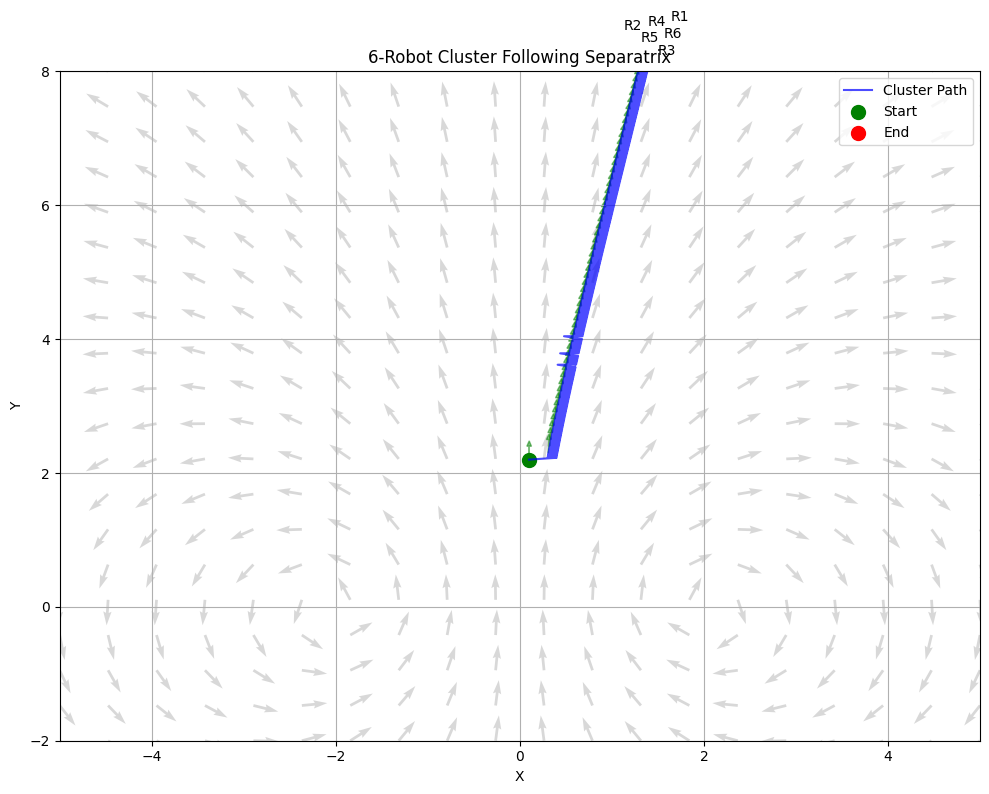


Final cluster centroid: [1.37252069 8.49133266]
Formation angle: 45.0 degrees (fixed)


In [22]:
if __name__ == "__main__":
    # Visualize the vector field
    print("Creating comprehensive field visualization...")
    fig_field = create_comprehensive_visualization(resolution=50)
    plt.show()

    # Simulate 6-robot cluster
    print("\n\nSimulating 6-Robot Cluster")
    print("="*50)
    
    centroid_hist, eigvec_hist, robots = simulate_separatrix_following(
        n_steps=600,
        step_size=0.01,
        correction_weight=10.09,
        verbose=True
    )
    
    fig = visualize_results(centroid_hist, eigvec_hist, robots)
    plt.show()
    
    print(f"\nFinal cluster centroid: {robots.centroid}")
    print(f"Formation angle: {robots.formation_angle * 180 / np.pi:.1f} degrees (fixed)")